# Micrograd — Karpathy Neural Networks: Zero to Hero, Video 1

**Video:** https://www.youtube.com/watch?v=VMj-3S1tku0  
**Reference repo:** `../nn-zero-to-hero/lectures/micrograd/`

## How to use this notebook

Each section rebuilds the `Value` class with whatever Karpathy added at that point in the video, so every section is self-contained and shows *what was new*. The final Value class (Section 6) is the one you'd use for real work.

**Every time you open this notebook:** `Kernel → Restart Kernel and Run All Cells`. Because `Value` is redefined multiple times, running cells out of order will use the wrong version.

## Rules I followed while learning this

1. **TYPE. Do not paste.** Every line goes through your fingers.
2. **Pause the video** when Karpathy writes a new function or class — try to write it yourself before he finishes, then compare.
3. **Break things on purpose.** After each section works, change something (a parameter, a sign, an operator) and predict what will happen. Then run it.
4. **Log what surprised you.** Not what the code does — what you didn't expect.

Session log at the bottom.

## Section 1 — Derivatives, a warm-up

First 10–15 min of the video. Define a simple function, evaluate its derivative numerically, and see what happens as the step size `h` shrinks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# f(x) = 3x^2 - 4x + 5. Predict f(3.0) before running.
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)  # expected: 20.0

20.0

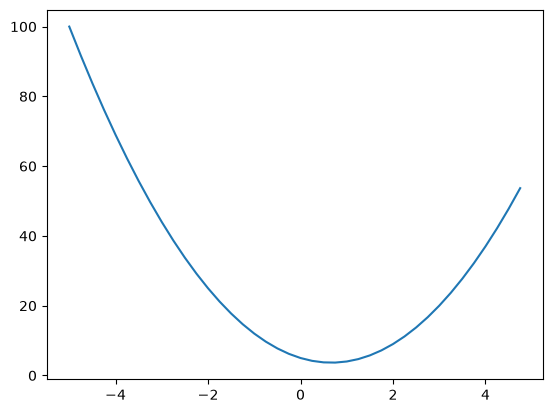

In [3]:
# Plot f over x in [-5, 5]
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [4]:
# Numerical derivative at x = 3.0.
# Try h = 1e-3, 1e-6, 1e-10. What changes? Why?
x = 3.0
for h in (1e-3, 1e-6, 1e-10):
    print(f"h={h:g}  slope={(f(x + h) - f(x)) / h}")
# True derivative at x=3 is 14.
# Too-small h → catastrophic cancellation (subtracting two nearly-equal floats loses precision).

h=0.001  slope=14.00300000000243
h=1e-06  slope=14.000003002223593
h=1e-10  slope=14.000001158365194


## Section 2 — Multivariable numerical derivatives

`d = a*b + c`. Nudge each input in turn to estimate ∂d/∂a, ∂d/∂b, ∂d/∂c numerically. Predict the sign and magnitude of each before running.

In [5]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)  # 4.0

4.0


In [6]:
# Numerical partials via forward perturbation on each variable.
h = 1e-4
d_fn = lambda a, b, c: a*b + c

print(f"∂d/∂a ≈ {(d_fn(a+h, b, c) - d_fn(a, b, c)) / h}")  # expected: b  = -3
print(f"∂d/∂b ≈ {(d_fn(a, b+h, c) - d_fn(a, b, c)) / h}")  # expected: a  =  2
print(f"∂d/∂c ≈ {(d_fn(a, b, c+h) - d_fn(a, b, c)) / h}")  # expected: 1

∂d/∂a ≈ -3.000000000010772
∂d/∂b ≈ 2.0000000000042206
∂d/∂c ≈ 0.9999999999976694


## Section 3 — The `Value` class (minimal)

Now the real work begins. Build a class that wraps a number and tracks its parents (the expression tree). At this stage: `__init__`, `__repr__`, `__add__`, `__mul__` — nothing else yet.

In [7]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def trace(self, depth=0):
        """My own helper: recursively print the expression tree from this node.
        Not part of Karpathy's Value — added to lock in my mental model of _prev."""
        print("  " * depth + repr(self) + f" ({self._op or 'leaf'})")
        for child in self._prev:
            child.trace(depth + 1)

In [8]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c

print(d)              # Value(data=4.0)
print(d._prev)        # { Value(-6.0), Value(10.0) } — parents of d
print(d._op)          # '+'
d.trace()             # full tree from d

Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)}
+
Value(data=4.0) (+)
  Value(data=-6.0) (*)
    Value(data=2.0) (leaf)
    Value(data=-3.0) (leaf)
  Value(data=10.0) (leaf)


## Section 4 — Visualizing the graph

Add a `label` attribute so nodes have names, then use graphviz to draw the computation graph.

**Requires:** `brew install graphviz` at the system level and `graphviz` in the Python env (both installed in this project). The `os.environ` line below is the fix for a running Jupyter server that didn't inherit `/opt/homebrew/bin` on its PATH.

In [9]:
# Rebuild Value with a `label` attribute so draw_dot can name each node.
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

In [10]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]  # ensure the `dot` binary is findable
from graphviz import Digraph

def trace(root):
    """Walk the graph from `root` and collect all nodes and edges."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left-to-right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data), shape='record')
        if n._op:
            # small oval for each op node, feeding into its result Value
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

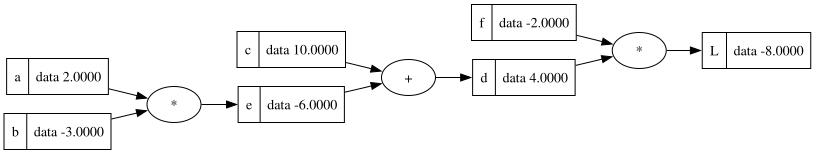

In [11]:
# A slightly bigger expression: L = d*f where d = a*b + c
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'

draw_dot(L)

## Section 5 — Manual backprop

Add `.grad = 0.0` to every Value and a `tanh` operation. Then walk the graph *backward by hand*, assigning gradients one node at a time using the chain rule. This is the conceptual peak of the video — everything after is automation.

**The two patterns to internalize:**
- **Addition distributes gradient unchanged.** If `d = e + c`, then `e.grad += d.grad` and `c.grad += d.grad` (local derivative = 1).
- **Multiplication swaps and multiplies.** If `e = a*b`, then `a.grad += b.data * e.grad` and `b.grad += a.data * e.grad`.
- **tanh's local derivative** is `1 - tanh(x)^2` — captured as `1 - t**2` where `t` was the computed output.

In [12]:
import math

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        return Value(t, (self,), 'tanh')

In [13]:
# Upgrade draw_dot to show `grad` in each record.
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,
                 label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [14]:
# Karpathy's one-neuron expression: o = tanh(w1*x1 + w2*x2 + b)
# b is chosen so tanh's output is a clean 0.7071 (= 1/sqrt(2)) — makes hand-math easy.
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

print(f"o.data = {o.data}")  # ~0.7071

o.data = 0.7071067811865476


w1.grad = 0.9999999999999998
w2.grad = 0.0
x1.grad = -1.4999999999999996
x2.grad = 0.4999999999999999


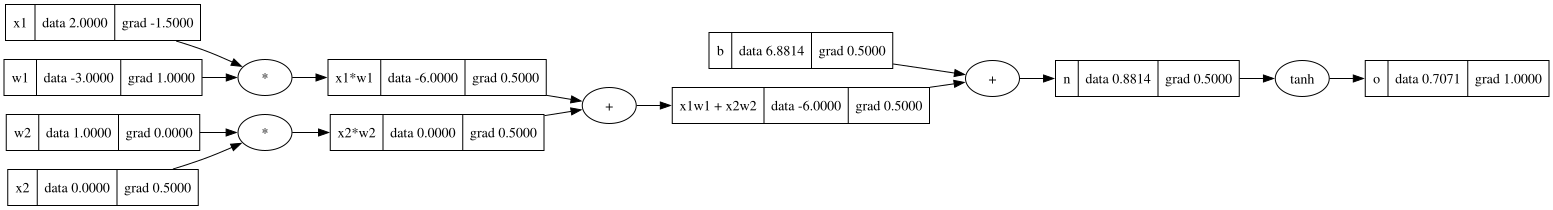

In [15]:
# Manually set gradients by walking the graph BACKWARD from o.
# Predict each before running.
o.grad = 1.0                                # ∂o/∂o = 1
n.grad = (1 - o.data**2) * o.grad           # tanh derivative × downstream grad
x1w1x2w2.grad = 1.0 * n.grad                # + distributes grad unchanged
b.grad = 1.0 * n.grad
x1w1.grad = 1.0 * x1w1x2w2.grad             # + again
x2w2.grad = 1.0 * x1w1x2w2.grad
x1.grad = w1.data * x1w1.grad               # * uses OTHER operand
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

# Expected: w1=1.0, w2=0.0, x1=-1.5, x2=0.5
# Note: w2.grad = 0 because x2 = 0 — a weight can't learn if its input is dead.
print(f"w1.grad = {w1.grad}")
print(f"w2.grad = {w2.grad}")
print(f"x1.grad = {x1.grad}")
print(f"x2.grad = {x2.grad}")

draw_dot(o)

## Section 6 — Automatic backprop with `_backward`

Teach each operation how to distribute gradient to its parents. Every op attaches a `_backward` closure that captures its inputs and the output. A single `.backward()` on the output node does a topological sort of the graph and calls each `_backward` in reverse order — reproducing what you did by hand in Section 5, automatically.

**The critical gotcha:** gradients must **accumulate** (`+=`), not overwrite (`=`). If a variable appears twice in an expression (`a + a`, or a weight used across a batch), each path must contribute to its total gradient. Miss this and gradients silently corrupt.

**Also new here:** auto-wrapping non-Value operands (so `a + 1` and `2 * a` work), plus `__pow__`, `exp`, `__truediv__`, `__rmul__`, `__radd__`, `__neg__`, `__sub__` so we have the full set of ops needed to decompose complex expressions and use `sum()`, subtraction, division naturally.

In [16]:
import math

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None  # leaves have no-op backward
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):        # enables 2 * Value(3)
        return self * other

    def __radd__(self, other):        # enables sum([...], start=0) with Values
        return self + other

    def __neg__(self):                # -self
        return self * -1

    def __sub__(self, other):         # self - other
        return self + (-other)

    def __truediv__(self, other):     # self / other = self * other**-1
        return self * other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad   # d/dx exp(x) = exp(x) = out.data
        out._backward = _backward
        return out

    def backward(self):
        """Topological sort of the graph, then walk in reverse calling each _backward."""
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def trace(self, depth=0):
        print("  " * depth + repr(self) + f" ({self._op or 'leaf'})")
        for child in self._prev:
            child.trace(depth + 1)

w1.grad = 0.9999999999999998
w2.grad = 0.0
x1.grad = -1.4999999999999996
x2.grad = 0.4999999999999999


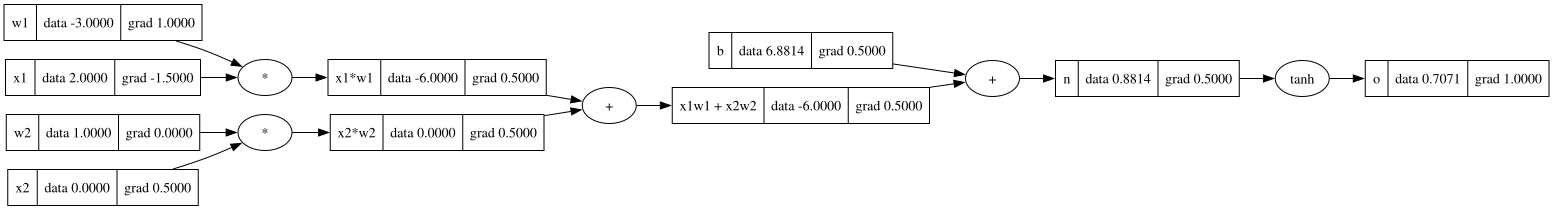

In [17]:
# Rebuild the neuron using the new Value (must re-run so _backward closures exist).
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

# Should match Section 5 exactly: w1=1.0, w2=0.0, x1=-1.5, x2=0.5
print(f"w1.grad = {w1.grad}")
print(f"w2.grad = {w2.grad}")
print(f"x1.grad = {x1.grad}")
print(f"x2.grad = {x2.grad}")

draw_dot(o)

In [18]:
# Gotcha 1 — accumulation. If += is wrong anywhere, a+a would give a.grad = 1.0 (wrong).
a = Value(3.0, label='a')
b = a + a
b.backward()
print(f"a + a: a.grad = {a.grad}  (expected 2.0)")

# Gotcha 2 — __pow__. Should give a.grad = 2*a = 6.0.
a = Value(3.0, label='a')
y = a**2
y.backward()
print(f"a**2: a.grad = {a.grad}  (expected 6.0)")

# Gotcha 3 — mixing Values with Python numbers via auto-wrap and __rmul__.
a = Value(3.0)
print(f"a + 1 = {a + 1}")
print(f"2 * a = {2 * a}")

a + a: a.grad = 2.0  (expected 2.0)
a**2: a.grad = 6.0  (expected 6.0)
a + 1 = Value(data=4.0)
2 * a = Value(data=6.0)


## Section 7 — Neuron, Layer, MLP

Now that autograd works, wrap it in three tiny classes to build a real neural network. Each class is a thin organizer around the layer below it — the `Value` class does not change here.

- **`Neuron(nin)`** — owns `nin` weights + one bias, all `Value`s. Forward pass: `tanh(w · x + b)`.
- **`Layer(nin, nout)`** — a list of `nout` neurons, all seeing the same input.
- **`MLP(nin, nouts)`** — a stack of `Layer`s, threading each output as the next's input.

Each class also exposes `parameters()` — a flat list of every trainable `Value` in it. Used by the training loop to iterate over all weights + biases for the update step and for zeroing grads.

In [19]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # tanh(w · x + b). Starting sum() at self.b avoids Python int + Value dance.
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        # Unwrap single-output layers so downstream code sees a Value, not a 1-element list.
        # Matters for the final layer of an MLP so y.backward() works directly.
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts   # e.g. MLP(3, [4, 4, 1]) → sz = [3, 4, 4, 1]
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

parameters: 41
first-layer w[0].grad = -0.24763452141011716


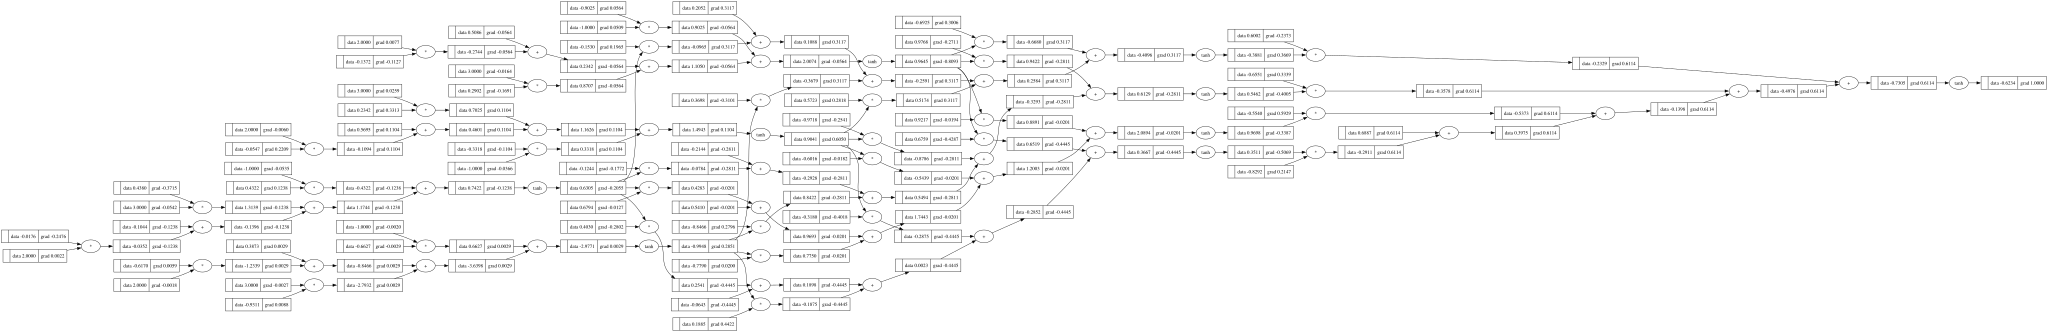

In [20]:
# Sanity check: forward pass + backprop through a whole network.
# Predict len(n.parameters()) before running.
# MLP(3, [4, 4, 1]) has: (3+1)*4 + (4+1)*4 + (4+1)*1 = 16 + 20 + 5 = 41 parameters.
n = MLP(3, [4, 4, 1])
print(f"parameters: {len(n.parameters())}")

y = n([2.0, 3.0, -1.0])          # forward pass → single Value
y.backward()                      # backprop through the whole network
print(f"first-layer w[0].grad = {n.layers[0].neurons[0].w[0].grad}")
# Some small float. Small magnitude foreshadows vanishing gradients — see session log.
draw_dot(y)                       # this graph is MASSIVE — enjoy it

## Section 8 — Train a tiny model on a toy dataset

Karpathy's 4-example, 3-feature dataset (roughly XOR-ish). Loss = sum of squared errors. Manual gradient descent loop.

**The `zero_grad` gotcha:** because `_backward` uses `+=` to accumulate, gradients from iteration `k` will leak into iteration `k+1` unless we explicitly reset `p.grad = 0` before each `loss.backward()`. Karpathy actually forgets this the first time in the video — watch for the moment he notices the training going haywire and adds the zero-grad line.

In [21]:
xs = [[2.0,  3.0, -1.0],
      [3.0, -1.0,  0.5],
      [0.5,  1.0,  1.0],
      [1.0,  1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

In [22]:
# Baseline: MLP(3, [4, 4, 1]) at lr = 0.05, 100 iterations.
# Watch iteration 6-ish for a small loss spike — that's overshoot from a too-large step.
# Expected final loss: ~0.003 (varies with random init).
n = MLP(3, [4, 4, 1])
lr = 0.05

for k in range(100):
    # 1. Forward: compute predictions for all 4 examples
    ypred = [n(x) for x in xs]
    # 2. Loss: sum of squared errors
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # 3. Zero grads BEFORE backward — else `+=` accumulates across iterations
    for p in n.parameters():
        p.grad = 0.0
    # 4. Backward: fill in every parameter's .grad
    loss.backward()
    # 5. Update: step each parameter in the negative-gradient direction
    for p in n.parameters():
        p.data += -lr * p.grad

    print(k, loss.data)

ypred   # final 4 predictions — should be close to [1, -1, -1, 1]

0 2.970253896263122
1 1.3533951856284414
2 0.809457894320926
3 0.510236161131377
4 0.308304588517224
5 0.2178115505042279
6 0.17437937052433455
7 0.14463494406437433
8 0.12304650487554819
9 0.1067512178613148
10 0.09406329739918283
11 0.08393265231033474
12 0.0756745467702806
13 0.06882515193522723
14 0.06306002707058203
15 0.05814593155044305
16 0.05391118485947735
17 0.05022679790160841
18 0.046994095881429776
19 0.04413638275362708
20 0.04159319514063484
21 0.0393162581800967
22 0.037266585745582885
23 0.03541236606130364
24 0.03372739640522836
25 0.032189908194201186
26 0.030781673897677428
27 0.029487320282342397
28 0.028293794670805093
29 0.027189946028453482
30 0.026166193172019618
31 0.02521425975385206
32 0.024326960913304933
33 0.0234980302587093
34 0.0227219785908583
35 0.02199397780127792
36 0.021309764881893324
37 0.02066556211060004
38 0.020058010330853696
39 0.01948411289471702
40 0.018941188339625076
41 0.018426830257053252
42 0.01793887311381766
43 0.017475363024251588

[Value(data=0.9637092304565215),
 Value(data=-0.9688733596504118),
 Value(data=-0.9536492787889536),
 Value(data=0.9491244520986137)]

### Ablations — pick the right learning rate and the right model size

The baseline converges cleanly, but two other runs make the tradeoffs concrete.

In [23]:
# Ablation 1 — lr too small. 50x smaller step size → ~50x slower convergence.
# Loss decreases monotonically (no oscillations) but ends nowhere near the baseline.
# After 100 iters at lr=0.001: loss ~1.0, predictions weakly saturated (~0.4 to 0.8 magnitude).
# Would need ~5000 iters to match the baseline result.
n = MLP(3, [4, 4, 1])
lr = 0.001

for k in range(100):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    for p in n.parameters():
        p.data += -lr * p.grad
    print(k, loss.data)

ypred

0 5.0453255258591065
1 5.00121587442099
2 4.956631538327372
3 4.911604707855225
4 4.866170668574565
5 4.8203677830350475
6 4.774237435164919
7 4.727823934285639
8 4.681174376250756
9 4.634338459990184
10 4.587368258673432
11 4.540317945781364
12 4.493243477567892
13 4.446202234663869
14 4.399252626877696
15 4.352453666526656
16 4.305864516829534
17 4.25954402294384
18 4.213550234080614
19 4.167939925724681
20 4.122768131286557
21 4.078087692487619
22 4.033948837422479
23 3.990398794560735
24 3.947481449971516
25 3.905237053822353
26 3.863701980777188
27 3.822908547364275
28 3.782884887776467
29 3.7436548879768616
30 3.705238176480342
31 3.6676501688254772
32 3.6309021615891224
33 3.5950014708608635
34 3.5599516094050774
35 3.525752496298465
36 3.4924006926320907
37 3.4598896568891373
38 3.4282100138251637
39 3.397349831053302
40 3.367294898036535
41 3.338029002776925
42 3.3095342021328538
43 3.281791082358989
44 3.2547790071230422
45 3.228476350886531
46 3.202860716127058
47 3.17790913

[Value(data=0.4297297308255862),
 Value(data=0.030663334323301178),
 Value(data=-0.5167611562326621),
 Value(data=0.15772503493099857)]

In [24]:
# Ablation 2 — smaller network. MLP(3, [2, 1]) has 11 params vs baseline's 41.
# Occam's razor test: does the dataset actually need the extra capacity?
# Result: converges just as well (final loss ~0.007) and MORE smoothly — no iter-6 bump,
# because the smaller model has a simpler loss surface with fewer directions to overshoot in.
n = MLP(3, [2, 1])
print(f"parameters: {len(n.parameters())}")
lr = 0.05

for k in range(100):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    for p in n.parameters():
        p.data += -lr * p.grad
    print(k, loss.data)

ypred

parameters: 11
0 7.119365526693503
1 6.726727251053264
2 5.9445790087867705
3 4.280048334621599
4 1.8870513251337067
5 1.0109064784679074
6 0.7546404560273656
7 0.5877988157351277
8 0.47281259646979884
9 0.3907563633997304
10 0.33024651094404867
11 0.2842965948807209
12 0.24850113484112335
13 0.2199959846782031
14 0.1968622534487895
15 0.17777786924399028
16 0.16180850002767472
17 0.1482785591178951
18 0.13668942884623753
19 0.12666627412865475
20 0.11792262042989057
21 0.1102362429556227
22 0.10343242418902457
23 0.09737211366118054
24 0.09194341334483819
25 0.08705535996418426
26 0.082633320185058
27 0.07861553578593658
28 0.07495050041745946
29 0.07159494562101389
30 0.06851227866236474
31 0.06567135921987513
32 0.06304553288980942
33 0.060611861248164464
34 0.058350503731842994
35 0.056244217794228404
36 0.05427795194638278
37 0.0524385122987389
38 0.05071428767931853
39 0.04909502174915566
40 0.047571623064353134
41 0.046136005961336365
42 0.04478095662162912
43 0.0435000198168393

[Value(data=0.9534849442592048),
 Value(data=-0.9493554543679772),
 Value(data=-0.9242839429463227),
 Value(data=0.9237373860991643)]

## Session log

### What clicked
- **Differentiation via small h.** The smaller the h, the more it represents the slope *at* a point rather than *over* a span. But there's a floor — see the first question below.
- **Product rule as swap.** ∂(a·b)/∂a = b and ∂(a·b)/∂b = a. The derivative w.r.t. one operand is just the *other* operand.
- **Value objects.** Wrapping a number in a class lets you track *how* it was computed, not just what it equals. That's the whole trick behind autograd.
- **Chain rule = product of local derivatives along the path.** Section 5's hand-work made this concrete: `∂o/∂x1 = ∂o/∂n × ∂n/∂x1w1x2w2 × ∂x1w1x2w2/∂x1w1 × ∂x1w1/∂x1` — every arrow contributes a factor.
- **Dead inputs → dead weights.** `w2.grad = 0` in the neuron because `x2 = 0`. A weight only learns when its input is nonzero. This is a real ML principle (see: dead ReLU neurons, weight initialization).
- **Add distributes; multiply swaps.** The two backprop rules that cover almost everything. `tanh` adds a third: `1 - tanh²`.
- **`+=` matters.** Overwriting instead of accumulating silently corrupts gradients when a variable appears more than once.
- **Closures tie `_backward` to the operation that created it.** When `__add__` returns `out`, it also attaches a `_backward` function that already remembers `self`, `other`, and `out` — so calling `out._backward()` later can still reach back and modify the correct parents' `.grad`. This is why the automation works.
- **`Neuron` → `Layer` → `MLP` is just organization.** The Value class doesn't change in Section 7. Each wrapper is a list of the layer below it, plus a `parameters()` that flattens down to every trainable `Value`. That's what makes the training loop clean.
- **Zero grads BEFORE `.backward()`, not after.** Because `_backward` uses `+=`, any grads left from the previous iteration will contaminate the new ones. Karpathy actually forgets this the first time in the video.
- **Vanishing gradient.** Heard of it, knew ReLU helps, but never really understood *why* until Section 7. Each `tanh` derivative is ≤ 1, so gradients passing through multiple tanh layers get multiplied by fractions on every hop — shrinking as they walk back toward early layers. First-layer weight in a 3→4→4→1 tanh MLP saw a gradient of just ~0.02 for the same input that produced an output near ±1. That's *the* motivation for ReLU (derivative = 1 for positive x, no shrinkage), skip connections (ResNet — gradient highway), and normalization (batch norm keeps activations in tanh's linear region).
- **The learning-rate tradeoff, seen directly.** Baseline lr=0.05: converged in ~10 iters but had a loss *spike* at iter 6 (overshoot). Ablation 1 lr=0.001: smooth monotonic decay but nowhere near converged after 100 iters. Too high → oscillate/diverge. Too low → waste compute. This is the intuition behind learning rate schedules, momentum, and gradient clipping.
- **Small networks are often enough.** MLP(3, [2, 1]) with 11 params fit the dataset as well as MLP(3, [4, 4, 1]) with 41 — and trained more smoothly. Occam's razor for ML: start small, scale up only when the small model plateaus. The 4x4 architecture was over-provisioned for a 4-example dataset.

### Questions I had (and the answers I found)

**Q: Why is numerical differentiation with too-small `h` incorrect? How would I prevent it?**  
*A: **Catastrophic cancellation.** When `h` is tiny, `f(x+h)` and `f(x)` differ only in their last few bits of float precision — subtracting them throws away most of the signal and leaves noise. Fixes: (1) use a **central difference** `(f(x+h) - f(x-h)) / (2h)` — cancels the leading error term, giving accurate results even at moderate `h`. (2) Don't do numerical differentiation at all — the whole video is about the alternative: **symbolic autograd**, which is exact and cheap.*

**Q: Why does `d._prev.pop()._prev` sometimes return an empty set?**  
*A: **Two things at once.** (1) `set.pop()` returns an arbitrary element — order determined by hash values, not insertion. Sometimes it pops the leaf (empty `_prev`), sometimes the intermediate (non-empty). (2) `pop()` **mutates** the set — every call destroys a parent link, so repeated runs eventually error out. Non-destructive alternative: `next(iter(d._prev))._prev` or `list(d._prev)[0]._prev`.*

**Q: Can I lock in the order of `_prev` so `pop()` is deterministic?**  
*A: **Not with a `set`.** If deterministic order matters, use `sorted(d._prev, key=lambda v: v.label)` for peeking, or change `_prev = list(_children)` in `__init__` (but that loses dedup — see next question).*

**Q: Why use `set` for `_prev` instead of `list`?**  
*A: **Three reasons.** (1) **Deduplication** — `a + a` would have `_prev = (a, a)` as a tuple; sets fold that to `{a}` so backprop visits `a` once from the `+` node. (2) **O(1) membership** for `if v not in nodes` in `trace()`, vs O(n) for lists — matters on large graphs. (3) **Order doesn't matter for correctness** — gradients accumulate additively, and the topological sort in `backward()` handles ordering when it matters. The tradeoff Karpathy accepts: non-deterministic iteration in `draw_dot`.*

**Q: Why does `draw_dot` iterate nodes in a different order than `trace()` built them?**  
*A: **Same underlying fact** — `trace()` stores nodes in a `set`, and iterating a set doesn't give insertion order (unlike `dict`, which does since Python 3.7). Doesn't affect correctness; edges are still drawn correctly. If you wanted stable layout, replace `nodes = set()` with `nodes = {}` (dict-as-ordered-set) and add via `nodes[v] = None`.*

**Q: What is the purpose of the underscore prefix on methods and attributes like `_prev`, `_op`, `_backward`, `_children`?**  
*A: **Python convention for "internal use."** A single leading underscore signals "this is an implementation detail — don't touch it from outside the class." Nothing enforces it (unlike `private` in Java) — it's a social contract. Karpathy uses it to mark the graph-tracking machinery (`_prev`, `_op`, `_backward`) as distinct from the user-facing API (`data`, `grad`, `label`, `backward`, `tanh`). If you saw someone writing `foo._prev.pop()` in production code, you'd know they were poking at internals. (Double leading underscores like `__init__` are different — those are Python-defined "dunder" methods.)*

**Q: How does `_backward` on an operation's output affect the previous value's gradient?**  
*A: **Closures.** When `__add__` runs, it defines the local function `_backward()` that references `self`, `other`, and `out`. Python captures those variable bindings in the function's closure — they stick around even after `__add__` returns. So when you later call `out._backward()`, it can still reach back and modify `self.grad` and `other.grad`, because it still holds references to those exact objects. This is why the automation works: each op leaves behind a personalized `_backward` that knows exactly which parents to update and by how much. Your intuition ("the `_backward` function stored, not called, within the operation method is tied to the previous value") is exactly right.*

### Still-open questions
(none right now)